<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/04_construction_review_indicators_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# การตรวจรูปแบบโครงการจ้างก่อสร้าง ปีงบประมาณ 2569

ข้อมูล e-GP ปีงบประมาณ 2569 สะสมถึงวันที่ 30 กรกฎาคม 2569 ไม่ใช่ข้อมูลเต็มปี

ผลลัพธ์ใช้สำหรับจัดลำดับการตรวจเอกสาร ไม่ใช่หลักฐานว่ามีการทุจริตหรือแบ่งซื้อแบ่งจ้าง

In [47]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
fm.fontManager.addfont('thsarabunnew-webfont.ttf')

sns.set_theme(style='whitegrid', font='TH Sarabun New')

plt.rcParams.update({
    'axes.titlesize': 18,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.unicode_minus': False
})

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

BLUE = '#5B7FA3'
ORANGE = '#D9822B'
GRAY = '#B8C2CC'
TEXT = '#344054'
MUTED = '#667085'
GRID = '#E4E7EC'

In [49]:
processed_dir = Path(
    '/content/drive/MyDrive/learning/dads/dads5001/'
    'project_1_dads5001/dataset/procurement/'
    'egp-contract/processed'
)

figure_dir = processed_dir.parents[3] / 'figure'
figure_dir.mkdir(parents=True, exist_ok=True)

project_path = processed_dir / 'construction_projects_2569.csv'
contract_path = processed_dir / 'construction_contracts_2569.csv'

project_data = pd.read_csv(project_path, low_memory=False)
contract_data = pd.read_csv(contract_path, low_memory=False)

In [50]:
project_id_column = 'รหัสโครงการ'
project_name_column = 'ชื่อโครงการจัดซื้อจัดจ้าง'
agency_column = 'ชื่อหน่วยงาน'
subagency_column = 'ชื่อหน่วยงานย่อย'
province_column = 'จังหวัด'
method_column = 'ชื่อวิธีการจัดซื้อจัดจ้าง'
budget_column = 'วงเงินงบประมาณ (บาท)'
awarded_price_column = 'ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)'
transaction_date_column = 'วันที่เกิดรายการ'
contract_value_column = 'วงเงินงบประมาณในสัญญา (บาท)'
supplier_id_column = 'เลขประจำตัวนิติบุคคล 13 หลัก'
supplier_name_column = 'ชื่อผู้ชนะการเสนอราคา'

specific_method_value = 'เฉพาะเจาะจง'
legal_budget_ceiling = 500_000

project_data['in_study_scope'] = (
    project_data[method_column].eq(specific_method_value)
    & project_data[budget_column].le(legal_budget_ceiling)
)

study_project_data = project_data.loc[
    project_data['in_study_scope']
].copy()

study_project_ids = set(
    study_project_data[project_id_column]
)

study_summary = pd.Series({
    'โครงการก่อสร้างทั้งหมด': len(project_data),
    'โครงการในกลุ่มศึกษา': len(study_project_data),
    'สัดส่วนโครงการทั้งหมด (%)': (
        len(study_project_data) / len(project_data) * 100
    )
}, name='value')

display(study_summary.to_frame())

,value
โครงการก่อสร้างทั้งหมด,"178,978.00"
โครงการในกลุ่มศึกษา,"136,070.00"
สัดส่วนโครงการทั้งหมด (%),76.03


In [51]:
project_supplier_data = (
    contract_data
    .groupby(
        [project_id_column, supplier_id_column]
    )
    .agg(
        supplier_name=(supplier_name_column, 'first'),
        supplier_awarded_value=(contract_value_column, 'sum')
    )
    .reset_index()
    .merge(
        project_data[
            [
                project_id_column,
                project_name_column,
                agency_column,
                subagency_column,
                province_column,
                method_column,
                budget_column,
                awarded_price_column,
                transaction_date_column,
                'in_study_scope'
            ]
        ],
        on=project_id_column,
        how='left'
    )
)

## 1. Pattern 1 — โครงการใกล้เพดานที่เกิดซ้ำ

ตรวจโครงการวิธีเฉพาะเจาะจง วงเงิน 490,000–500,000 บาท ที่พบในคู่หน่วยงานย่อย–ผู้รับจ้างเดียวกันอย่างน้อย 3 โครงการ

วันที่เกิดรายการไม่นำมาเป็นเงื่อนไข เพราะการคลาดกันเพียง 1 วันทำให้หลุดจาก Pattern ได้ วันที่จะแสดงไว้ในตารางรายโครงการเพื่อใช้เปิดเอกสารประกอบเท่านั้น


In [52]:
valid_cluster_rows = (
    project_supplier_data[subagency_column].notna()
    & project_supplier_data[supplier_id_column].notna()
)

near_ceiling_data = project_supplier_data.loc[
    project_supplier_data['in_study_scope']
    & valid_cluster_rows
    & project_supplier_data[budget_column].between(
        490_000,
        legal_budget_ceiling,
        inclusive='both'
    )
].copy()

cluster_columns = [
    subagency_column,
    supplier_id_column
]

near_ceiling_clusters = (
    near_ceiling_data
    .groupby(cluster_columns, dropna=False)
    .agg(
        supplier_name=('supplier_name', 'first'),
        project_count=(project_id_column, 'nunique'),
        total_budget=(budget_column, 'sum')
    )
    .reset_index()
)

repeated_clusters = (
    near_ceiling_clusters.loc[
        near_ceiling_clusters['project_count'].ge(3)
    ]
    .sort_values(
        ['project_count', 'total_budget'],
        ascending=False
    )
    .reset_index(drop=True)
)

pattern1_project_ids = set(
    near_ceiling_data
    .merge(
        repeated_clusters[cluster_columns],
        on=cluster_columns,
        how='inner'
    )[project_id_column]
)

project_data['flag_pattern_1'] = (
    project_data[project_id_column].isin(pattern1_project_ids)
)

pattern1_summary = pd.Series({
    'คู่หน่วยงาน–ผู้รับจ้างที่ผ่านเกณฑ์': len(repeated_clusters),
    'โครงการที่เกี่ยวข้อง': project_data['flag_pattern_1'].sum(),
    'สัดส่วนกลุ่มศึกษา (%)': (
        project_data['flag_pattern_1'].sum()
        / len(study_project_data)
        * 100
    )
}, name='ค่า')

pattern1_table = (
    repeated_clusters[
        [
            subagency_column,
            'supplier_name',
            'project_count',
            'total_budget'
        ]
    ]
    .rename(columns={
        subagency_column: 'หน่วยงานย่อย',
        'supplier_name': 'ผู้รับจ้าง',
        'project_count': 'จำนวนโครงการ',
        'total_budget': 'วงเงินรวม (บาท)'
    })
)

display(pattern1_summary.to_frame())
display(pattern1_table.head(15))


,ค่า
คู่หน่วยงาน–ผู้รับจ้างที่ผ่านเกณฑ์,"2,341.00"
โครงการที่เกี่ยวข้อง,"12,763.00"
สัดส่วนกลุ่มศึกษา (%),9.38


,หน่วยงานย่อย,ผู้รับจ้าง,จำนวนโครงการ,วงเงินรวม (บาท)
0,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,บริษัท บ้านบุ่ง วิศวกรรม จำกัด,93,"46,314,000.00"
1,องค์การบริหารส่วนจังหวัดนครพนม,บริษัท พนมนาคราช (2021) จำกัด,79,"38,860,000.00"
2,องค์การบริหารส่วนจังหวัดขอนแก่น,ห้างหุ้นส่วนจำกัด ด.โชคชัยโยธา,70,"34,968,000.00"
3,องค์การบริหารส่วนจังหวัดขอนแก่น,ห้างหุ้นส่วนจำกัด ทวีทรัพย์สหกิจ,42,"20,980,000.00"
4,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,บริษัท น้ำดีบาดาล จำกัด,42,"20,958,000.00"
5,องค์การบริหารส่วนจังหวัดนครพนม,ห้างหุ้นส่วนจำกัด บัญชาศรีสงครามก่อสร้าง,42,"20,881,000.00"
6,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,ห้างหุ้นส่วนจำกัด สุราอาจสามารถ,41,"20,459,000.00"
7,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,ห้างหุ้นส่วนจำกัด เด็พซัน,40,"19,960,000.00"
8,องค์การบริหารส่วนจังหวัดศรีสะเกษ,ดวินวัฒน์,38,"18,947,000.00"
9,องค์การบริหารส่วนจังหวัดศรีสะเกษ,ห้างหุ้นส่วนจำกัด มณีสุดา,38,"18,943,000.00"


### อ่านตาราง Pattern 1

แต่ละแถวคือคู่หน่วยงานย่อย–ผู้รับจ้างหนึ่งคู่ จำนวนโครงการนับเฉพาะโครงการวิธีเฉพาะเจาะจงที่มีวงเงิน 490,000–500,000 บาท โดยรวมทุกวันที่เกิดรายการ

ตารางเรียงจากคู่ที่มีจำนวนโครงการมากที่สุด เพื่อให้เห็นกลุ่มที่ควรเปิดดูรายละเอียดก่อน


## 2. Pattern 2 — การพึ่งพาผู้รับจ้างภายในหน่วยงาน

ตรวจ 2 ระดับตามลำดับ:

1. หน่วยงานใหญ่–ผู้รับจ้าง
2. หน่วยงานย่อย–ผู้รับจ้าง

แต่ละคู่ต้องมีอย่างน้อย 10 โครงการ และผู้รับจ้างครองทั้งจำนวนโครงการและวงเงินอย่างน้อย 75% ของหน่วยงานในระดับนั้น


In [53]:
study_supplier_data = project_supplier_data.loc[
    project_supplier_data['in_study_scope']
    & project_supplier_data[supplier_id_column].notna()
].copy()

agency_supplier_relationships = (
    study_supplier_data.loc[
        study_supplier_data[agency_column].notna()
    ]
    .groupby(
        [agency_column, supplier_id_column],
        dropna=False
    )
    .agg(
        supplier_name=('supplier_name', 'first'),
        supplier_project_count=(project_id_column, 'nunique'),
        supplier_awarded_value=('supplier_awarded_value', 'sum')
    )
    .reset_index()
)

agency_totals = (
    study_project_data.loc[
        study_project_data[agency_column].notna()
    ]
    .groupby(agency_column, dropna=False)
    .agg(
        organization_project_count=(project_id_column, 'nunique'),
        organization_awarded_value=(awarded_price_column, 'sum')
    )
    .reset_index()
)

agency_supplier_relationships = (
    agency_supplier_relationships
    .merge(
        agency_totals,
        on=agency_column,
        how='left'
    )
)

agency_supplier_relationships['project_share_pct'] = (
    agency_supplier_relationships['supplier_project_count']
    / agency_supplier_relationships['organization_project_count']
    * 100
)

agency_supplier_relationships['value_share_pct'] = (
    agency_supplier_relationships['supplier_awarded_value']
    / agency_supplier_relationships['organization_awarded_value']
    * 100
)

subagency_supplier_relationships = (
    study_supplier_data.loc[
        study_supplier_data[subagency_column].notna()
    ]
    .groupby(
        [subagency_column, supplier_id_column],
        dropna=False
    )
    .agg(
        supplier_name=('supplier_name', 'first'),
        supplier_project_count=(project_id_column, 'nunique'),
        supplier_awarded_value=('supplier_awarded_value', 'sum')
    )
    .reset_index()
)

subagency_totals = (
    study_project_data.loc[
        study_project_data[subagency_column].notna()
    ]
    .groupby(subagency_column, dropna=False)
    .agg(
        organization_project_count=(project_id_column, 'nunique'),
        organization_awarded_value=(awarded_price_column, 'sum')
    )
    .reset_index()
)

subagency_supplier_relationships = (
    subagency_supplier_relationships
    .merge(
        subagency_totals,
        on=subagency_column,
        how='left'
    )
)

subagency_supplier_relationships['project_share_pct'] = (
    subagency_supplier_relationships['supplier_project_count']
    / subagency_supplier_relationships['organization_project_count']
    * 100
)

subagency_supplier_relationships['value_share_pct'] = (
    subagency_supplier_relationships['supplier_awarded_value']
    / subagency_supplier_relationships['organization_awarded_value']
    * 100
)


In [54]:
agency_high_dependence = (
    agency_supplier_relationships.loc[
        agency_supplier_relationships['supplier_project_count'].ge(10)
        & agency_supplier_relationships['project_share_pct'].ge(75)
        & agency_supplier_relationships['value_share_pct'].ge(75)
    ]
    .sort_values(
        ['project_share_pct', 'supplier_project_count'],
        ascending=False
    )
    .reset_index(drop=True)
)

subagency_high_dependence = (
    subagency_supplier_relationships.loc[
        subagency_supplier_relationships['supplier_project_count'].ge(10)
        & subagency_supplier_relationships['project_share_pct'].ge(75)
        & subagency_supplier_relationships['value_share_pct'].ge(75)
    ]
    .sort_values(
        ['project_share_pct', 'supplier_project_count'],
        ascending=False
    )
    .reset_index(drop=True)
)

agency_dependence_context = (
    study_supplier_data
    .drop(columns=['supplier_awarded_value'])
    .merge(
        agency_high_dependence[
            [
                agency_column,
                supplier_id_column,
                'supplier_project_count',
                'organization_project_count',
                'project_share_pct',
                'supplier_awarded_value',
                'organization_awarded_value',
                'value_share_pct'
            ]
        ],
        on=[agency_column, supplier_id_column],
        how='inner'
    )
    .rename(columns={
        'supplier_awarded_value': 'dependence_supplier_awarded_value',
        'organization_awarded_value': 'dependence_organization_awarded_value'
    })
    .assign(
        organization_level='หน่วยงานใหญ่',
        organization_name=lambda data: data[agency_column]
    )
)

subagency_dependence_context = (
    study_supplier_data
    .drop(columns=['supplier_awarded_value'])
    .merge(
        subagency_high_dependence[
            [
                subagency_column,
                supplier_id_column,
                'supplier_project_count',
                'organization_project_count',
                'project_share_pct',
                'supplier_awarded_value',
                'organization_awarded_value',
                'value_share_pct'
            ]
        ],
        on=[subagency_column, supplier_id_column],
        how='inner'
    )
    .rename(columns={
        'supplier_awarded_value': 'dependence_supplier_awarded_value',
        'organization_awarded_value': 'dependence_organization_awarded_value'
    })
    .assign(
        organization_level='หน่วยงานย่อย',
        organization_name=lambda data: data[subagency_column]
    )
)

pattern2_context = pd.concat(
    [
        agency_dependence_context,
        subagency_dependence_context
    ],
    ignore_index=True
)

pattern2_project_ids = set(
    pattern2_context[project_id_column]
)

project_data['flag_pattern_2'] = (
    project_data[project_id_column].isin(pattern2_project_ids)
)

high_dependence_relationships = pd.concat(
    [
        agency_high_dependence.rename(
            columns={agency_column: 'organization_name'}
        ).assign(organization_level='หน่วยงานใหญ่'),
        subagency_high_dependence.rename(
            columns={subagency_column: 'organization_name'}
        ).assign(organization_level='หน่วยงานย่อย')
    ],
    ignore_index=True
)

high_dependence_relationships = (
    high_dependence_relationships[
        [
            'organization_level',
            'organization_name',
            supplier_id_column,
            'supplier_name',
            'supplier_project_count',
            'organization_project_count',
            'project_share_pct',
            'supplier_awarded_value',
            'organization_awarded_value',
            'value_share_pct'
        ]
    ]
    .sort_values(
        ['project_share_pct', 'supplier_project_count'],
        ascending=False
    )
    .reset_index(drop=True)
)

pattern2_summary = pd.DataFrame({
    'ระดับหน่วยงาน': [
        'หน่วยงานใหญ่',
        'หน่วยงานย่อย',
        'รวมโครงการที่เกี่ยวข้อง'
    ],
    'จำนวนคู่ที่ผ่านเกณฑ์': [
        len(agency_high_dependence),
        len(subagency_high_dependence),
        pd.NA
    ],
    'จำนวนโครงการ': [
        agency_dependence_context[project_id_column].nunique(),
        subagency_dependence_context[project_id_column].nunique(),
        len(pattern2_project_ids)
    ]
})

pattern2_table = (
    high_dependence_relationships
    .round({
        'project_share_pct': 2,
        'value_share_pct': 2
    })
    .rename(columns={
        'organization_level': 'ระดับหน่วยงาน',
        'organization_name': 'หน่วยงาน',
        'supplier_name': 'ผู้รับจ้าง',
        'supplier_project_count': 'โครงการของผู้รับจ้าง',
        'organization_project_count': 'โครงการทั้งหมดของหน่วยงาน',
        'project_share_pct': 'สัดส่วนจำนวนโครงการ (%)',
        'supplier_awarded_value': 'วงเงินของผู้รับจ้าง (บาท)',
        'organization_awarded_value': 'วงเงินรวมของหน่วยงาน (บาท)',
        'value_share_pct': 'สัดส่วนวงเงิน (%)'
    })
)

display(pattern2_summary)
display(pattern2_table.head(20))


,ระดับหน่วยงาน,จำนวนคู่ที่ผ่านเกณฑ์,จำนวนโครงการ
0,หน่วยงานใหญ่,115,1915
1,หน่วยงานย่อย,142,2421
2,รวมโครงการที่เกี่ยวข้อง,<NA>,2421


,ระดับหน่วยงาน,หน่วยงาน,เลขประจำตัวนิติบุคคล 13 หลัก,ผู้รับจ้าง,โครงการของผู้รับจ้าง,โครงการทั้งหมดของหน่วยงาน,สัดส่วนจำนวนโครงการ (%),วงเงินของผู้รับจ้าง (บาท),วงเงินรวมของหน่วยงาน (บาท),สัดส่วนวงเงิน (%)
0,หน่วยงานใหญ่,เทศบาลตำบลบ้านโปร่ง,0413555002704,ห้างหุ้นส่วนจำกัด สมจินตนาวงษ์เจริญ คอนกรีต,73,73,100.00,"7,974,800.00","7,974,800.00",100.00
1,หน่วยงานย่อย,เทศบาลตำบลบ้านโปร่ง,0413555002704,ห้างหุ้นส่วนจำกัด สมจินตนาวงษ์เจริญ คอนกรีต,73,73,100.00,"7,974,800.00","7,974,800.00",100.00
2,หน่วยงานใหญ่,องค์การบริหารส่วนตำบลเมืองพลับพลา,0303564008672,ห้างหุ้นส่วนจำกัด เอสพี 1971,24,24,100.00,"9,490,000.00","9,490,000.00",100.00
3,หน่วยงานใหญ่,เทศบาลตำบลโป่งน้ำร้อน,371030009xxxx,นายชาญ ทองดี,24,24,100.00,"8,244,000.00","8,244,000.00",100.00
4,หน่วยงานย่อย,องค์การบริหารส่วนตำบลเมืองพลับพลา,0303564008672,ห้างหุ้นส่วนจำกัด เอสพี 1971,24,24,100.00,"9,490,000.00","9,490,000.00",100.00
5,หน่วยงานย่อย,เทศบาลตำบลโป่งน้ำร้อน,371030009xxxx,นายชาญ ทองดี,24,24,100.00,"8,244,000.00","8,244,000.00",100.00
6,หน่วยงานใหญ่,เทศบาลตำบลพรรณานคร,0473559000854,ห้างหุ้นส่วน กันตา คอนกรีต,21,21,100.00,"5,050,466.78","5,050,466.78",100.00
7,หน่วยงานย่อย,เทศบาลตำบลพรรณานคร,0473559000854,ห้างหุ้นส่วน กันตา คอนกรีต,21,21,100.00,"5,050,466.78","5,050,466.78",100.00
8,หน่วยงานย่อย,การไฟฟ้าส่วนภูมิภาคอำเภอนครหลวง,0135560025487,บริษัท นพพันธ์ อิเลคทริค จำกัด,19,19,100.00,"4,734,504.97","4,734,504.97",100.00
9,หน่วยงานย่อย,อุทยานแห่งชาติดอยสุเทพ-ปุย,0505564016012,บริษัท ฟอเรสต์ อินฟินิท แอนด์ คอนซัลติ้งค์ จำกัด,19,19,100.00,"4,217,889.92","4,217,889.92",100.00


### อ่านตาราง Pattern 2

แต่ละแถวคือคู่หน่วยงาน–ผู้รับจ้าง โดยคอลัมน์ระดับหน่วยงานบอกว่าเป็นผลจากหน่วยงานใหญ่หรือหน่วยงานย่อย

- โครงการของผู้รับจ้างเทียบกับโครงการทั้งหมดของหน่วยงาน ใช้ดูสัดส่วนความถี่
- วงเงินของผู้รับจ้างเทียบกับวงเงินรวมของหน่วยงาน ใช้ดูสัดส่วนงบประมาณ

ตารางเรียงตามสัดส่วนจำนวนโครงการจากมากไปน้อย เพื่อไม่ให้หน่วยงานที่มีจำนวนโครงการหรือวงเงินมากได้ลำดับสูงเพียงเพราะมีขนาดใหญ่


## 3. Pattern 3 — การพึ่งพาผู้รับจ้างภายในจังหวัด

ตรวจว่ามีผู้รับจ้างรายใดครองทั้งจำนวนโครงการและมูลค่าตั้งแต่ 50% ภายในจังหวัดหรือไม่ โดยพิจารณาจังหวัดที่มีอย่างน้อย 20 โครงการและผู้รับจ้างที่ได้รับอย่างน้อย 5 โครงการ

In [55]:
valid_geographic_data = study_supplier_data.loc[
    study_supplier_data[province_column].notna()
    & ~study_supplier_data[province_column]
    .astype('string')
    .str.strip()
    .isin(['', '-', 'ไม่ระบุ'])
].copy()

province_supplier_relationships = (
    valid_geographic_data
    .groupby(
        [province_column, supplier_id_column],
        dropna=False
    )
    .agg(
        supplier_name=('supplier_name', 'first'),
        supplier_project_count=(project_id_column, 'nunique'),
        supplier_awarded_value=('supplier_awarded_value', 'sum')
    )
    .reset_index()
)

province_totals = (
    study_project_data.loc[
        study_project_data[province_column].notna()
        & ~study_project_data[province_column]
        .astype('string')
        .str.strip()
        .isin(['', '-', 'ไม่ระบุ'])
    ]
    .groupby(province_column, dropna=False)
    .agg(
        province_project_count=(project_id_column, 'nunique'),
        province_awarded_value=(awarded_price_column, 'sum')
    )
    .reset_index()
)

province_supplier_relationships = (
    province_supplier_relationships
    .merge(
        province_totals,
        on=province_column,
        how='left'
    )
)

province_supplier_relationships['project_share_pct'] = (
    province_supplier_relationships['supplier_project_count']
    / province_supplier_relationships['province_project_count']
    * 100
)

province_supplier_relationships['value_share_pct'] = (
    province_supplier_relationships['supplier_awarded_value']
    / province_supplier_relationships['province_awarded_value']
    * 100
)

pattern3_table = (
    province_supplier_relationships
    .sort_values('project_share_pct', ascending=False)
    [
        [
            province_column,
            'supplier_name',
            'supplier_project_count',
            'province_project_count',
            'project_share_pct',
            'value_share_pct'
        ]
    ]
    .rename(columns={
        province_column: 'จังหวัด',
        'supplier_name': 'ผู้รับจ้าง',
        'supplier_project_count': 'โครงการของผู้รับจ้าง',
        'province_project_count': 'โครงการทั้งหมดในจังหวัด',
        'project_share_pct': 'ส่วนแบ่งจำนวนโครงการ (%)',
        'value_share_pct': 'ส่วนแบ่งมูลค่า (%)'
    })
)

display(pattern3_table.head(15))


,จังหวัด,ผู้รับจ้าง,โครงการของผู้รับจ้าง,โครงการทั้งหมดในจังหวัด,ส่วนแบ่งจำนวนโครงการ (%),ส่วนแบ่งมูลค่า (%)
21945,สมุทรสาคร,บริษัท วอเตอร์ คอนเซ็ปต์ จำกัด,51,353,14.45,10.93
21572,สตูล,ห้างหุ้นส่วนจำกัด แอล . พี . เค คอนกรีต,45,321,14.02,4.26
30390,เพชรบุรี,ห้างหุ้นส่วนจำกัด ธนภัทร รุ่งเรือง ก่อสร้าง,99,769,12.87,15.12
16552,ยะลา,บริษัท พี.เจ.37 พาราวู้ด จำกัด,34,419,8.11,12.30
5464,ชุมพร,ห้างหุ้นส่วนจำกัด พันธ์เจริญธุรกิจ,87,1076,8.09,10.38
5978,ตราด,ห้างหุ้นส่วนจำกัด เพชรเมืองตราด,39,497,7.85,12.70
5448,ชุมพร,ห้างหุ้นส่วนจำกัด สมใจทองคำการโยธา,82,1076,7.62,4.81
19049,ลำปาง,ห้างหุ้นส่วนจำกัด ตั้นอ้าย วิศวกรรม,168,2257,7.44,8.84
21906,สมุทรสงคราม,นางสาวอโรชา อนงค์รัตนกุล,16,224,7.14,1.05
21887,สมุทรสงคราม,บริษัท โรงเลื่อยจักรประสาร จำกัด,15,224,6.70,9.42


In [56]:
eligible_province_relationships = (
    province_supplier_relationships.loc[
        province_supplier_relationships['province_project_count'].ge(20)
        & province_supplier_relationships['supplier_project_count'].ge(5)
    ]
    .copy()
)

geographic_dominance_relationships = (
    eligible_province_relationships.loc[
        eligible_province_relationships['project_share_pct'].ge(50)
        & eligible_province_relationships['value_share_pct'].ge(50)
    ]
    .copy()
)

geographic_summary = pd.Series({
    'คู่จังหวัด–ผู้รับจ้างที่ผ่านเกณฑ์': (
        len(geographic_dominance_relationships)
    ),
    'ส่วนแบ่งจำนวนโครงการสูงสุด (%)': (
        eligible_province_relationships['project_share_pct'].max()
    ),
    'ส่วนแบ่งมูลค่าสูงสุด (%)': (
        eligible_province_relationships['value_share_pct'].max()
    )
}, name='value')

display(geographic_summary.to_frame())

,value
คู่จังหวัด–ผู้รับจ้างที่ผ่านเกณฑ์,0.00
ส่วนแบ่งจำนวนโครงการสูงสุด (%),14.45
ส่วนแบ่งมูลค่าสูงสุด (%),15.12


### อ่านตาราง Pattern 3

แต่ละแถวคือคู่จังหวัด–ผู้รับจ้าง ตารางเรียงตามส่วนแบ่งจำนวนโครงการจากมากไปน้อย เพื่อดูว่ามีผู้รับจ้างรายใดครองงานในจังหวัดสูงผิดปกติหรือไม่

ผลนี้ใช้เป็นบริบทเท่านั้น เพราะไม่มีคู่ใดผ่านเกณฑ์การพึ่งพาระดับจังหวัด จึงไม่นำ Pattern 3 ไปคัดโครงการตรวจสอบลำดับแรก


## 4. โครงการที่เข้าเงื่อนไขทั้งสอง Pattern

In [57]:
pattern1_context = (
    near_ceiling_data
    .merge(
        repeated_clusters[
            cluster_columns + ['project_count']
        ].rename(columns={
            'project_count': 'cluster_project_count'
        }),
        on=cluster_columns,
        how='inner'
    )
)

priority_context = (
    pattern1_context
    .merge(
        pattern2_context[
            [
                project_id_column,
                supplier_id_column,
                'organization_level',
                'organization_name',
                'supplier_project_count',
                'organization_project_count',
                'project_share_pct',
                'dependence_supplier_awarded_value',
                'dependence_organization_awarded_value',
                'value_share_pct'
            ]
        ],
        on=[
            project_id_column,
            supplier_id_column
        ],
        how='inner'
    )
)

priority_project_ids = set(
    priority_context[project_id_column]
)

study_review_data = project_data.loc[
    project_data['in_study_scope']
].copy()

study_review_data['flag_pattern_1'] = (
    study_review_data[project_id_column]
    .isin(pattern1_project_ids)
)

study_review_data['flag_pattern_2'] = (
    study_review_data[project_id_column]
    .isin(pattern2_project_ids)
)

study_review_data['priority_review'] = (
    study_review_data[project_id_column]
    .isin(priority_project_ids)
)

result_summary = pd.DataFrame({
    'เงื่อนไข': [
        'เกิดซ้ำใกล้เพดาน',
        'พึ่งพาผู้รับจ้างสูง',
        'เข้าเงื่อนไขทั้งสองข้อ'
    ],
    'จำนวนโครงการ': [
        study_review_data['flag_pattern_1'].sum(),
        study_review_data['flag_pattern_2'].sum(),
        study_review_data['priority_review'].sum()
    ],
    'ความหมาย': [
        'วงเงิน 490,000–500,000 บาท และอยู่ในคู่หน่วยงานย่อย–ผู้รับจ้างที่มีอย่างน้อย 3 โครงการ',
        'ผู้รับจ้างมีสัดส่วนจำนวนโครงการและวงเงินอย่างน้อย 75% ในหน่วยงานใหญ่หรือหน่วยงานย่อย',
        'โครงการที่ควรเปิดเอกสารตรวจเป็นลำดับแรก'
    ]
})

display(result_summary)


,เงื่อนไข,จำนวนโครงการ,ความหมาย
0,เกิดซ้ำใกล้เพดาน,12763,"วงเงิน 490,000–500,000 บาท และอยู่ในคู่หน่วยงานย่อย–ผู้รับจ้างที่มีอย่างน้อย 3 โครงการ"
1,พึ่งพาผู้รับจ้างสูง,2421,ผู้รับจ้างมีสัดส่วนจำนวนโครงการและวงเงินอย่างน้อย 75% ในหน่วยงานใหญ่หรือหน่วยงานย่อย
2,เข้าเงื่อนไขทั้งสองข้อ,548,โครงการที่ควรเปิดเอกสารตรวจเป็นลำดับแรก


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig04_01_review_conditions.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig04_01_review_conditions.svg


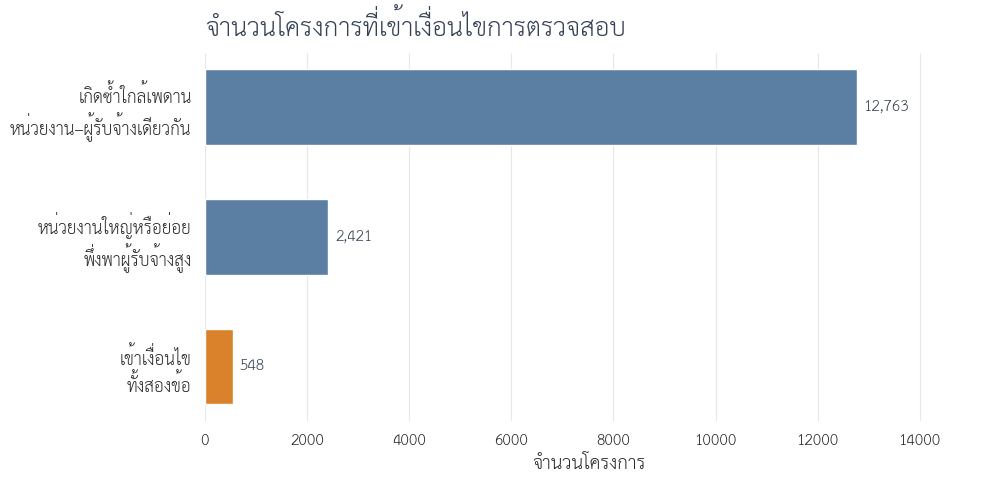

In [58]:
plot_data = pd.Series({
    'เกิดซ้ำใกล้เพดาน\nหน่วยงาน–ผู้รับจ้างเดียวกัน': (
        study_review_data['flag_pattern_1'].sum()
    ),
    'หน่วยงานใหญ่หรือย่อย\nพึ่งพาผู้รับจ้างสูง': (
        study_review_data['flag_pattern_2'].sum()
    ),
    'เข้าเงื่อนไข\nทั้งสองข้อ': (
        study_review_data['priority_review'].sum()
    )
})

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    plot_data.index,
    plot_data.values,
    color=[BLUE, BLUE, ORANGE],
    height=0.58
)

ax.bar_label(
    bars,
    labels=[f'{value:,.0f}' for value in plot_data.values],
    padding=5,
    fontsize=11,
    color=TEXT
)

ax.invert_yaxis()
ax.set_xlim(0, plot_data.max() * 1.18)
ax.set_title(
    'จำนวนโครงการที่เข้าเงื่อนไขการตรวจสอบ',
    loc='left',
    pad=12,
    color=TEXT
)
ax.set_xlabel('จำนวนโครงการ')
ax.set_ylabel('')

ax.grid(axis='x', color=GRID, linewidth=0.8)
ax.grid(axis='y', visible=False)
ax.set_axisbelow(True)
sns.despine(left=True, bottom=True)

fig.tight_layout()

png_path = figure_dir / 'fig04_01_review_conditions.png'
svg_path = figure_dir / 'fig04_01_review_conditions.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')


In [59]:
priority_projects = (
    priority_context[
        [
            project_id_column,
            project_name_column,
            agency_column,
            subagency_column,
            province_column,
            'organization_level',
            'organization_name',
            'supplier_name',
            budget_column,
            awarded_price_column,
            transaction_date_column,
            'cluster_project_count',
            'supplier_project_count',
            'organization_project_count',
            'project_share_pct',
            'dependence_supplier_awarded_value',
            'dependence_organization_awarded_value',
            'value_share_pct'
        ]
    ]
    .sort_values(
        [
            'project_share_pct',
            'cluster_project_count',
            budget_column
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

priority_groups = (
    priority_context
    .groupby(
        [
            'organization_level',
            'organization_name',
            supplier_id_column,
            'supplier_name'
        ],
        dropna=False
    )
    .agg(
        priority_project_count=(project_id_column, 'nunique'),
        cluster_project_count=('cluster_project_count', 'max'),
        supplier_project_count=('supplier_project_count', 'max'),
        organization_project_count=('organization_project_count', 'max'),
        project_share_pct=('project_share_pct', 'max'),
        dependence_supplier_awarded_value=('dependence_supplier_awarded_value', 'max'),
        dependence_organization_awarded_value=('dependence_organization_awarded_value', 'max'),
        value_share_pct=('value_share_pct', 'max')
    )
    .reset_index()
    .sort_values(
        [
            'project_share_pct',
            'priority_project_count',
            'cluster_project_count'
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

priority_group_table = (
    priority_groups[
        [
            'organization_level',
            'organization_name',
            'supplier_name',
            'priority_project_count',
            'supplier_project_count',
            'organization_project_count',
            'project_share_pct',
            'dependence_supplier_awarded_value',
            'dependence_organization_awarded_value',
            'value_share_pct'
        ]
    ]
    .round({
        'project_share_pct': 2,
        'value_share_pct': 2
    })
    .rename(columns={
        'organization_level': 'ระดับหน่วยงาน',
        'organization_name': 'หน่วยงาน',
        'supplier_name': 'ผู้รับจ้าง',
        'priority_project_count': 'โครงการที่เข้าเงื่อนไขทั้งสองข้อ',
        'supplier_project_count': 'โครงการของผู้รับจ้าง',
        'organization_project_count': 'โครงการทั้งหมดของหน่วยงาน',
        'project_share_pct': 'สัดส่วนจำนวนโครงการ (%)',
        'dependence_supplier_awarded_value': 'วงเงินของผู้รับจ้าง (บาท)',
        'dependence_organization_awarded_value': 'วงเงินรวมของหน่วยงาน (บาท)',
        'value_share_pct': 'สัดส่วนวงเงิน (%)'
    })
)

priority_project_table = (
    priority_projects[
        [
            project_id_column,
            project_name_column,
            'organization_level',
            'organization_name',
            'supplier_name',
            transaction_date_column,
            budget_column,
            'project_share_pct',
            'value_share_pct'
        ]
    ]
    .round({
        'project_share_pct': 2,
        'value_share_pct': 2
    })
    .rename(columns={
        project_id_column: 'รหัสโครงการ',
        project_name_column: 'ชื่อโครงการ',
        'organization_level': 'ระดับหน่วยงาน',
        'organization_name': 'หน่วยงาน',
        'supplier_name': 'ผู้รับจ้าง',
        transaction_date_column: 'วันที่เกิดรายการ',
        budget_column: 'วงเงินงบประมาณ (บาท)',
        'project_share_pct': 'สัดส่วนจำนวนโครงการ (%)',
        'value_share_pct': 'สัดส่วนวงเงิน (%)'
    })
)

display(priority_group_table.head(20))
display(priority_project_table.head(20))

print(
    'คู่หน่วยงาน–ผู้รับจ้างที่ควรตรวจ: '
    f'{len(priority_groups):,}'
)
print(
    'โครงการตรวจสอบลำดับแรก: '
    f'{priority_context[project_id_column].nunique():,}'
)


,ระดับหน่วยงาน,หน่วยงาน,ผู้รับจ้าง,โครงการที่เข้าเงื่อนไขทั้งสองข้อ,โครงการของผู้รับจ้าง,โครงการทั้งหมดของหน่วยงาน,สัดส่วนจำนวนโครงการ (%),วงเงินของผู้รับจ้าง (บาท),วงเงินรวมของหน่วยงาน (บาท),สัดส่วนวงเงิน (%)
0,หน่วยงานย่อย,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,13,18,18,100.00,"8,556,000.00","8,556,000.00",100.00
1,หน่วยงานใหญ่,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,13,18,18,100.00,"8,556,000.00","8,556,000.00",100.00
2,หน่วยงานย่อย,สำนักงานทางหลวงชนบทที่ 10 (เชียงใหม่),ห้างหุ้นส่วนจำกัด ลำปาง ภาณุภัทร์ก่อสร้าง 2008,10,10,10,100.00,"4,890,000.00","4,890,000.00",100.00
3,หน่วยงานย่อย,องค์การบริหารส่วนตำบลเมืองพลับพลา,ห้างหุ้นส่วนจำกัด เอสพี 1971,10,24,24,100.00,"9,490,000.00","9,490,000.00",100.00
4,หน่วยงานใหญ่,องค์การบริหารส่วนตำบลเมืองพลับพลา,ห้างหุ้นส่วนจำกัด เอสพี 1971,10,24,24,100.00,"9,490,000.00","9,490,000.00",100.00
5,หน่วยงานย่อย,องค์การบริหารส่วนตำบลหน้าเขา,ห้างหุ้นส่วนจำกัด เอียดบัวการโยธา,9,10,10,100.00,"4,677,400.00","4,677,400.00",100.00
6,หน่วยงานใหญ่,องค์การบริหารส่วนตำบลหน้าเขา,ห้างหุ้นส่วนจำกัด เอียดบัวการโยธา,9,10,10,100.00,"4,677,400.00","4,677,400.00",100.00
7,หน่วยงานย่อย,องค์การบริหารส่วนตำบลบุ่งไหม,บริษัท เอสพี 81 คอนสตรัคชั่น จำกัด,6,16,16,100.00,"4,932,480.00","4,932,480.00",100.00
8,หน่วยงานใหญ่,องค์การบริหารส่วนตำบลบุ่งไหม,บริษัท เอสพี 81 คอนสตรัคชั่น จำกัด,6,16,16,100.00,"4,932,480.00","4,932,480.00",100.00
9,หน่วยงานย่อย,องค์การบริหารส่วนตำบลชีบน,ห้างหุ้นส่วนจำกัด มีสัมฤทธิ์ เอ็นจิเนียริ่ง,4,10,10,100.00,"3,545,300.00","3,545,300.00",100.00


,รหัสโครงการ,ชื่อโครงการ,ระดับหน่วยงาน,หน่วยงาน,ผู้รับจ้าง,วันที่เกิดรายการ,วงเงินงบประมาณ (บาท),สัดส่วนจำนวนโครงการ (%),สัดส่วนวงเงิน (%)
0,69029505235,จ้างก่อสร้างถนน คสล. บ้านท่าใหม่ หมู่ที่ ๑๒ สายทางคลองเหมืองใหม่ ต่อ โดยวิธีเฉพาะเจาะจง,หน่วยงานใหญ่,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,11 มี.ค. 69,"496,000.00",100.00,100.00
1,69029505235,จ้างก่อสร้างถนน คสล. บ้านท่าใหม่ หมู่ที่ ๑๒ สายทางคลองเหมืองใหม่ ต่อ โดยวิธีเฉพาะเจาะจง,หน่วยงานย่อย,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,11 มี.ค. 69,"496,000.00",100.00,100.00
2,69039190892,จ้างก่อสร้างถนน คสล. บ้านจางวาง หมู่ที่ ๗ ซอยร่วมใจสุขสันต์ ๕ สายทางบ้านจางวาง ๒ ต่อ ซอยร่วมใจสุ...,หน่วยงานใหญ่,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,26 มี.ค. 69,"496,000.00",100.00,100.00
3,69039190892,จ้างก่อสร้างถนน คสล. บ้านจางวาง หมู่ที่ ๗ ซอยร่วมใจสุขสันต์ ๕ สายทางบ้านจางวาง ๒ ต่อ ซอยร่วมใจสุ...,หน่วยงานย่อย,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,26 มี.ค. 69,"496,000.00",100.00,100.00
4,69059339537,จ้างก่อสร้างถนน คสล. บ้านวังโป่ง หมู่ที่ ๓ สายคลองเหมืองใหม่ โดยวิธีเฉพาะเจาะจง,หน่วยงานใหญ่,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,28 พ.ค. 69,"496,000.00",100.00,100.00
5,69059339537,จ้างก่อสร้างถนน คสล. บ้านวังโป่ง หมู่ที่ ๓ สายคลองเหมืองใหม่ โดยวิธีเฉพาะเจาะจง,หน่วยงานย่อย,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,28 พ.ค. 69,"496,000.00",100.00,100.00
6,69059340184,จ้างก่อสร้างถนน คสล. บ้านไทรหย่อน หมู่ที่ ๑๓ สายทางบ้านวังโป่ง สายทางบ้านไทรหย่อน ต่อ โดยวิธีเฉพ...,หน่วยงานใหญ่,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,28 พ.ค. 69,"496,000.00",100.00,100.00
7,69059340184,จ้างก่อสร้างถนน คสล. บ้านไทรหย่อน หมู่ที่ ๑๓ สายทางบ้านวังโป่ง สายทางบ้านไทรหย่อน ต่อ โดยวิธีเฉพ...,หน่วยงานย่อย,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,28 พ.ค. 69,"496,000.00",100.00,100.00
8,69029505166,จ้างก่อสร้างถนน คสล. บ้านหนองโก หมู่ที่ ๒ ซอยประชาสุขใจ ต่อ ซอยหนองแขม โดยวิธีเฉพาะเจาะจง,หน่วยงานใหญ่,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,11 มี.ค. 69,"495,000.00",100.00,100.00
9,69029505166,จ้างก่อสร้างถนน คสล. บ้านหนองโก หมู่ที่ ๒ ซอยประชาสุขใจ ต่อ ซอยหนองแขม โดยวิธีเฉพาะเจาะจง,หน่วยงานย่อย,องค์การบริหารส่วนตำบลลานบ่า,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,11 มี.ค. 69,"495,000.00",100.00,100.00


คู่หน่วยงาน–ผู้รับจ้างที่ควรตรวจ: 108
โครงการตรวจสอบลำดับแรก: 548


### อ่านผลลัพธ์และตรวจต่ออย่างไร

ตารางแรกสรุปเป็นคู่หน่วยงาน–ผู้รับจ้าง พร้อมระบุว่าเข้าเงื่อนไขในระดับหน่วยงานใหญ่หรือหน่วยงานย่อย และเรียงตามสัดส่วนจำนวนโครงการจากมากไปน้อย

ตารางที่สองเป็นรายโครงการภายในกลุ่มเหล่านั้น วันที่เกิดรายการแสดงเพื่อค้นเอกสารเท่านั้น ไม่ได้ใช้ตัดสินว่าโครงการเข้า Pattern หรือไม่

จำนวนโครงการตรวจสอบลำดับแรกไม่ใช่จำนวนโครงการทุจริต แต่เป็นคิวสำหรับเปิดดูขอบเขตงาน สถานที่ ระยะเวลาอนุมัติ ผู้เสนอราคา และเอกสารเสนอราคา โดยควรตรวจโครงการของคู่หน่วยงาน–ผู้รับจ้างเดียวกันเป็นชุด


## 5. สรุป

- Pattern 1 พิจารณาการเกิดซ้ำของคู่หน่วยงานย่อย–ผู้รับจ้าง โดยไม่ใช้วันที่เกิดรายการ
- Pattern 2 ตรวจการพึ่งพาผู้รับจ้างทั้งระดับหน่วยงานใหญ่และหน่วยงานย่อย
- การจัดลำดับ Pattern 2 ใช้สัดส่วนจำนวนโครงการ ไม่ใช้จำนวนโครงการหรือวงเงินเพียงอย่างเดียว
- Pattern 3 ใช้ดูบริบทระดับจังหวัด แต่ไม่พบคู่ที่ผ่านเกณฑ์ จึงไม่ใช้คัดโครงการลำดับแรก
- โครงการตรวจสอบลำดับแรกคือโครงการที่เข้า Pattern 1 และ Pattern 2 พร้อมกัน


## 6. บันทึกผลลัพธ์

In [60]:
project_flags = project_data[
    [project_id_column, 'in_study_scope']
].copy()

project_flags['flag_pattern_1'] = (
    project_flags[project_id_column].isin(pattern1_project_ids)
)

project_flags['flag_pattern_2'] = (
    project_flags[project_id_column].isin(pattern2_project_ids)
)

project_flags['priority_review'] = (
    project_flags[project_id_column].isin(priority_project_ids)
)

output_objects = {
    'project_review_indicators_2569.csv': project_flags,
    'priority_review_groups_2569.csv': priority_groups,
    'priority_review_projects_2569.csv': priority_projects,
    'repeated_near_500k_clusters_2569.csv': repeated_clusters,
    'high_supplier_dependence_2569.csv': high_dependence_relationships,
    'province_supplier_summary_2569.csv': province_supplier_relationships
}

export_records = []

for file_name, output_data in output_objects.items():
    output_path = processed_dir / file_name
    output_data.to_csv(
        output_path,
        index=False,
        encoding='utf-8-sig'
    )
    export_records.append({
        'file_name': file_name,
        'rows': len(output_data),
        'file_size_mb': output_path.stat().st_size / 1024**2
    })

export_summary = pd.DataFrame(export_records)
display(export_summary)

,file_name,rows,file_size_mb
0,project_review_indicators_2569.csv,178978,6.00
1,priority_review_groups_2569.csv,108,0.03
2,priority_review_projects_2569.csv,872,0.79
3,repeated_near_500k_clusters_2569.csv,2341,0.44
4,high_supplier_dependence_2569.csv,257,0.07
5,province_supplier_summary_2569.csv,32223,5.62
